
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


**MUHAMMAD AHMED**

**ROLL NO. 1950**

**SEC: B**

## Import Libraries

In [57]:
#Importing Libraries
import pandas as pd
import numpy as np
import time
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

print(" All Libraries Imported")


 All Libraries Imported


## Load Dataset

In [58]:
# Loading Dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.tail()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


## Exploratory Data Analysis

In [59]:
# Check Type and info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [60]:
# Check missing values
print(df.isnull().sum())
df.count() # Rows before removing duplicates


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


,0
Hours Studied,10000
Previous Scores,10000
Extracurricular Activities,10000
Sleep Hours,10000
Sample Question Papers Practiced,10000
Performance Index,10000


In [61]:
# Check Duplicate values
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)


number of duplicate rows:  (127, 6)


In [62]:
df = df.drop_duplicates() # Dropping
df.tail()
df.count() # After removing duplicates

,0
Hours Studied,9873
Previous Scores,9873
Extracurricular Activities,9873
Sleep Hours,9873
Sample Question Papers Practiced,9873
Performance Index,9873


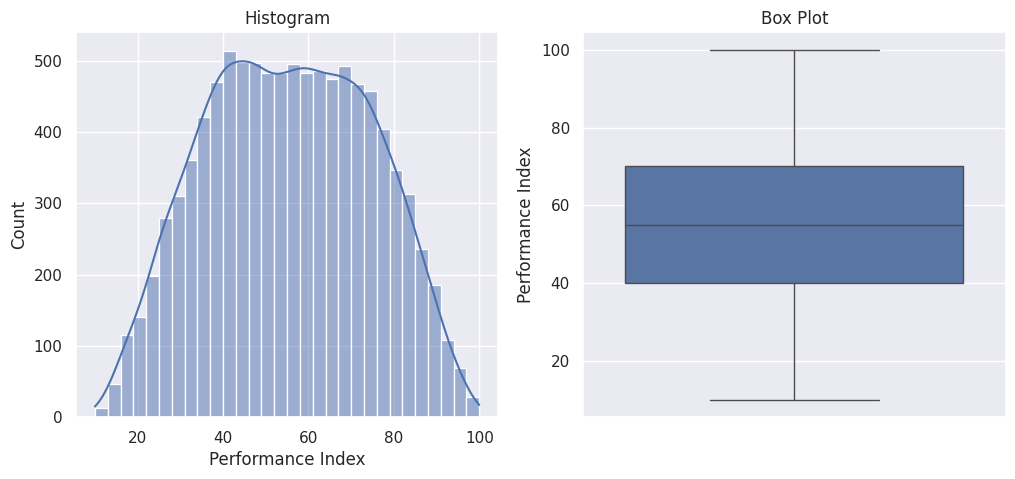

Skewness: -0.0
Kurtosis: -0.86


In [63]:
# Distibution Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Histogram")

plt.subplot(1,2,2)
sns.boxplot(y=df["Performance Index"])
plt.title("Box Plot")

plt.show()
print("Skewness:", round(df["Performance Index"].skew(), 2))
print("Kurtosis:", round(df["Performance Index"].kurt(), 2))

## Encoding (if needed)

In [64]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
df_encoded["Extracurricular Activities"] = le.fit_transform(df_encoded["Extracurricular Activities"])

In [65]:
# Convert to Dummy Variable
df = pd.get_dummies(df, columns=["Extracurricular Activities"], drop_first=True)
df = df.astype(int) # Convert True/False to 0/1
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


## Visualization

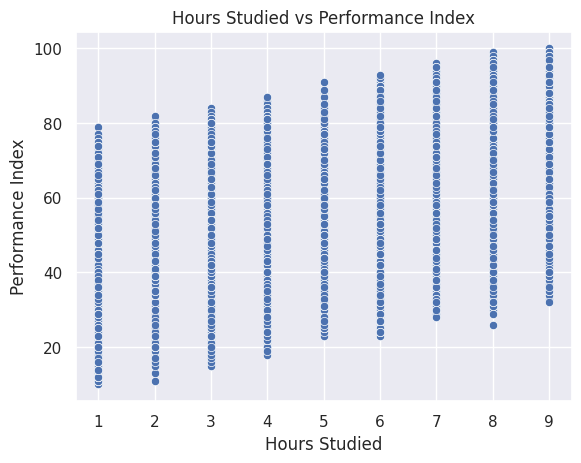

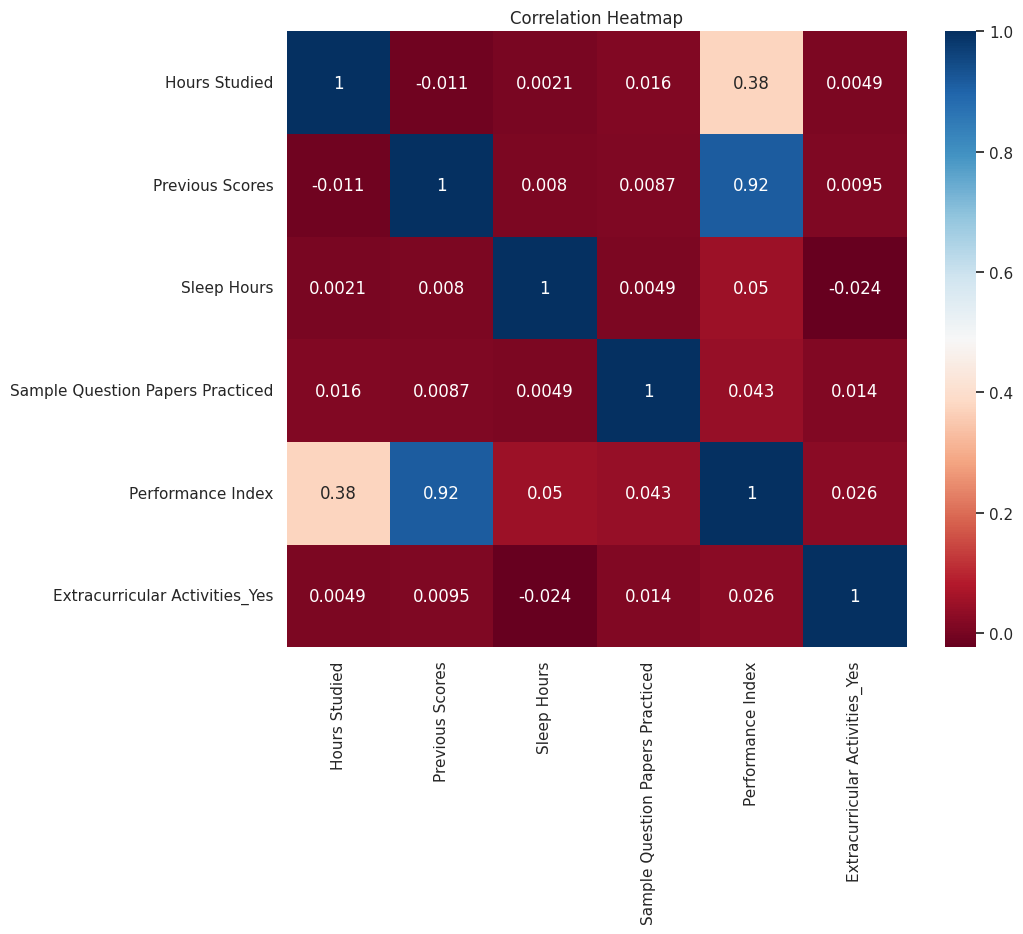

In [66]:
# Scatter plots
sns.scatterplot(x="Hours Studied", y="Performance Index", data=df)
plt.title("Hours Studied vs Performance Index")
plt.show()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="RdBu")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

In [67]:
# Compute correlation matrix
from tabulate import tabulate
corr = df.corr().round(3)
print(tabulate(corr, headers="keys", tablefmt="grid"))

+----------------------------------+-----------------+-------------------+---------------+------------------------------------+---------------------+----------------------------------+
|                                  |   Hours Studied |   Previous Scores |   Sleep Hours |   Sample Question Papers Practiced |   Performance Index |   Extracurricular Activities_Yes |
+==================================+=================+===================+===============+====================================+=====================+==================================+
| Hours Studied                    |           1     |            -0.011 |         0.002 |                              0.016 |               0.375 |                            0.005 |
+----------------------------------+-----------------+-------------------+---------------+------------------------------------+---------------------+----------------------------------+
| Previous Scores                  |          -0.011 |             1     | 

## Feature Selection

In [68]:
from sklearn.feature_selection import SelectKBest, f_regression

sel = SelectKBest(f_regression, k="all")
sel.fit(X_train, y_train)

scores = pd.DataFrame({"Feature": X.columns, "Score": sel.scores_.round(2)})
scores = scores.sort_values("Score", ascending=False)
print(scores.to_string(index=False))

                         Feature    Score
                 Previous Scores 40803.68
                   Hours Studied  1306.56
                     Sleep Hours    17.96
Sample Question Papers Practiced     7.98
  Extracurricular Activities_Yes     4.17


## Train-Test Split

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])
df.head()

Training samples: 7898
Testing  samples: 1975


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


## Feature Scaling (If needed)

In [70]:
from sklearn.preprocessing import StandardScaler

sx = StandardScaler()
sy = StandardScaler()

X_train_sc = sx.fit_transform(X_train)
X_test_sc  = sx.transform(X_test)

y_train_sc = sy.fit_transform(y_train.values.reshape(-1,1)).ravel()
print("Scaling done")

Scaling done


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [73]:
# Setup
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = {}

def save_result(name, y_test, y_pred, t_train, t_test):
    results[name] = {
        "MAE"          : round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE"         : round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "R2 Score"     : round(r2_score(y_test, y_pred), 4),
        "Train Time(s)": round(t_train, 4),
        "Test Time(s)" : round(t_test, 4)
    }
    print(f"\n{name}")
    print("R2  :", results[name]["R2 Score"])
    print("RMSE:", results[name]["RMSE"])
    print("MAE :", results[name]["MAE"])

In [82]:
# Linear Regression

from sklearn.linear_model import LinearRegression

t1 = time.time()
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
t2 = time.time()
y_pred_lr = lr.predict(X_test_sc)
t3 = time.time()
save_result("Linear Regression", y_test, y_pred_lr, t2-t1, t3-t2)


Linear Regression
R2  : 0.9884
RMSE: 2.08
MAE : 1.65


In [83]:
# SVR

from sklearn.svm import SVR

t1 = time.time()
svr = SVR(kernel="rbf")
svr.fit(X_train_sc, y_train_sc)
t2 = time.time()
y_pred_svr = sy.inverse_transform(svr.predict(X_test_sc).reshape(-1,1)).ravel()
t3 = time.time()

save_result("SVR", y_test, y_pred_svr, t2-t1, t3-t2)


SVR
R2  : 0.9878
RMSE: 2.13
MAE : 1.68


In [84]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

t1 = time.time()
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_sc, y_train)
t2 = time.time()
y_pred_dt = dt.predict(X_test_sc)
t3 = time.time()

save_result("Decision Tree", y_test, y_pred_dt, t2-t1, t3-t2)


Decision Tree
R2  : 0.9751
RMSE: 3.04
MAE : 2.42


In [85]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

t1 = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
t2 = time.time()
y_pred_rf = rf.predict(X_test_sc)
t3 = time.time()

save_result("Random Forest", y_test, y_pred_rf, t2-t1, t3-t2)


Random Forest
R2  : 0.9849
RMSE: 2.37
MAE : 1.9


In [86]:
# KNN

from sklearn.neighbors import KNeighborsRegressor

t1 = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train_sc)
t2 = time.time()
y_pred_knn = sy.inverse_transform(knn.predict(X_test_sc).reshape(-1,1)).ravel()
t3 = time.time()

save_result("KNN", y_test, y_pred_knn, t2-t1, t3-t2)


KNN
R2  : 0.9765
RMSE: 2.96
MAE : 2.36


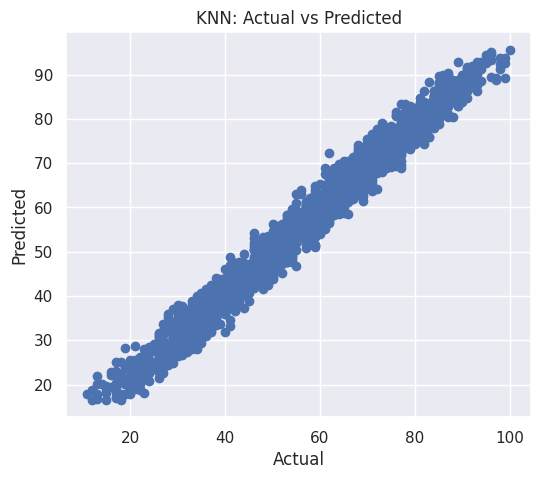

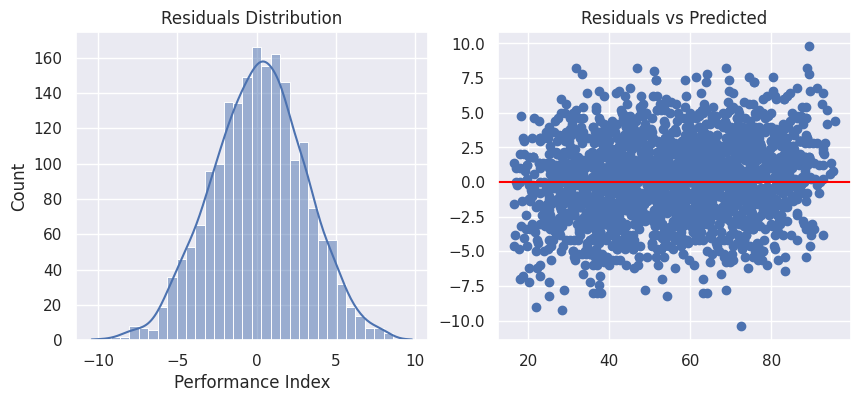

In [87]:
# KNN Plots
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN: Actual vs Predicted")
plt.show()

res = y_test - y_pred_knn
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(res, kde=True)
plt.title("Residuals Distribution")
plt.subplot(1,2,2)
plt.scatter(y_pred_knn, res)
plt.axhline(0, color="red")
plt.title("Residuals vs Predicted")
plt.show()

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?


**ANSWER**


### 1. What is a Decision Tree Regressor?
A Decision Tree is a model that asks a series of simple questions about the data to make a prediction.

*Example:*
```
Is Hours Studied > 5?
   Yes → Is Previous Score > 80?
              Yes → Predict 90
              No  → Predict 70
   No  → Predict 50
```
At the end of each branch it gives the average value of that group as the prediction.



### 2. What is Bootstrapping?
Bootstrapping means randomly picking rows from the dataset with repetition to create different smaller datasets.

*Example:*
```
Original data = [1, 2, 3, 4, 5]

Bootstrap Sample 1 = [1, 3, 3, 5, 2]
Bootstrap Sample 2 = [2, 2, 4, 1, 5]
Bootstrap Sample 3 = [3, 5, 1, 4, 4]
```
Each tree gets a different sample so every tree learns something slightly different.


### 3. How Are Multiple Trees Used?
Random Forest builds many Decision Trees like 100 trees where each tree is trained on a different bootstrap sample and also uses random features at each split.

```
Tree 1  →  Predicts: 75
Tree 2  →  Predicts: 78
Tree 3  →  Predicts: 74
...
Tree 100 → Predicts: 76
```
This makes trees diverse and reduces errors.


### 4. How is the Final Output Calculated?
For regression the final answer is simply the average of all tree predictions:

```
Final Output = (75 + 78 + 74 + ... + 76) / 100
             = 76.2
```
Averaging reduces overfitting and gives a much more accurate and stable result than a single tree.



### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

**ANSWER**


### 1. What is K?
K is simply a number that tells the model how many nearest neighbors to look at when making a prediction.

K = 3 → look at 3 closest points

K = 5 → look at 5 closest points

In our code we used K = 5 meaning it looks at the 5 most similar students to predict the score.

### 2. How Are Neighbors Selected?
KNN finds the closest data points by measuring the distance between the new point and all existing points.

Formula:
d = sqrt( (x1-y1)² + (x2-y2)² + ... + (xn-yn)² )

**Steps to Select Neighbors in KNN**

*Choose K:*

Decide how many nearest neighbors to consider for prediction.

*Calculate Distance:*

Measure the distance between the new data point and every point in the training data using Euclidean Distance formula.

*Sort Distances:*

Sort all the calculated distances in ascending order from smallest to largest.

*Select Top K:*

Pick the K points that have the smallest distances. These are the nearest neighbors.

*Predict:*

Take the average of the target values of those K neighbors as the final predicted output.



### 3. How is the Final Predicted Value Calculated?
For regression KNN simply takes the average of K neighbors scores.

Predicted Value = ( y1 + y2 + y3 + y4 + ..... + yk )/k

## Visualize Best Model

In [91]:
# Select best model based on R2
best = df_results["R2 Score"].idxmax()
print("Best Model:", best)
print("R2 Score  :", df_results.loc[best, "R2 Score"])

Best Model: Linear Regression
R2 Score  : 0.9884


## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [90]:
# Comparison Table
print("-"*70)
df_results = pd.DataFrame(results).T
print(df_results.to_string())
print("-"*70)

----------------------------------------------------------------------
                    MAE  RMSE  R2 Score  Train Time(s)  Test Time(s)
Linear Regression  1.65  2.08    0.9884         0.0039        0.0009
SVR                1.68  2.13    0.9878         1.6137        0.2419
Decision Tree      2.42  3.04    0.9751         0.0249        0.0011
Random Forest      1.90  2.37    0.9849         3.6285        0.0667
KNN                2.36  2.96    0.9765         0.0086        0.0193
----------------------------------------------------------------------


| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression |1.65 |2.08 |0.9884 |0.0039|0.0009|
| SVR |1.68 |2.13 |0.9878 |1.6137|0.2419|
| Decision Tree |2.42 |3.04 |0.9751 |0.0249|0.0011|
| Random Forest |1.90 | 2.37|0.9849 |3.6285|0.0667|
| KNN |2.36 |2.96 |0.9765 |0.0086|0.0193|

---